**This system leverages representations from RAVE. Learn more about that project here:** 
https://github.com/acids-ircam/RAVE

**Download more generative models from:** 
https://acids-ircam.github.io/rave_models_download

**Train your own model using:** 
https://colab.research.google.com/drive/1ih-gv1iHEZNuGhHPvCHrleLNXvooQMvI?usp=sharing (thanks to https://github.com/moiseshorta !)

**Giving Feedback** 
https://forms.office.com/Pages/DesignPageV2.aspx?prevorigin=Marketing&origin=NeoPortalPage&subpage=design&id=kfCdVhOw40CG7r2cueJYFFaGvjbF1INKikqB9y_N2gRUODBTNTJKM09HVjlFQjFRUlQ5U05QUVQ5MS4u&topview=Prefill

In [52]:
# In[0] # Load Utility Functions:
from load_generative_model import Model
from IPython.display import Audio, display
# from gui import interface
import librosa as li
import torch


import numpy as np
import os
from pathlib import Path
import IPython.display as ipd
from ipywidgets import interact, IntSlider
import matplotlib.pyplot as plt

import os
import random
import numpy as np
from ipywidgets import FloatSlider, IntSlider, interact, VBox, Label, fixed
from ipywidgets import Dropdown


In [46]:
# Working with trajectories in latent audio models

# In[1] # Pick Model:
model_name: str = 'percussion'
model_location:str = 'generative_models/'+model_name+'.ts'

control_model_location = 'control_models/vae_scripted_model.ts'
model = Model([model_location])
sr: int =44100

In [47]:
# In[2] # Pick Audio Samples:
# Get all sound files from the 'sounds' folder
sound_files = [f for f in os.listdir('sounds') if f.endswith(('.wav', '.aif', '.mp3', '.ogg'))]

# Select n random sounds
n = 8
selected_sounds = random.sample(sound_files, min(n, len(sound_files)))
# print(f"Selected sounds:")

encodings = [model.encode(li.load(audio_location,sr=44100)[0]) for audio_location in [os.path.join('sounds', sound) for sound in selected_sounds]]

# selected_sounds_recon = [model.decode(enc[0]) for enc in encodings]

In [ ]:
# Compute timbre features for each audio file and its encoding

def compute_features(sound_files):
    audio_features = []
    for sound_file in [os.path.join('sounds', sound) for sound in sound_files]:
        try:
            # Load audio file
            y, sr = li.load(sound_file, sr=None)
        
            # Encode and decode to ensure consistency
            encoded = model.encode(y)
            y = model.decode(encoded[0])

            # Compute spectral centroid
            spectral_centroid = li.feature.spectral_centroid(y=y, sr=sr)[0]
            
            # Take the mean spectral centroid across time
            mean_centroid = np.mean(spectral_centroid)
            
            # Compute spectral flatness
            spectral_flatness = li.feature.spectral_flatness(y=y)[0]
            mean_flatness = np.mean(spectral_flatness)

            # Compute zero crossing rate as another timbre feature
            zero_crossings = li.feature.zero_crossing_rate(y)[0]
            mean_zero_crossings = np.mean(zero_crossings)
            
            audio_features.append({
                'file': sound_file,
                'filename': Path(sound_file).name,
                'spectral_centroid': mean_centroid,
                'spectral_flatness': mean_flatness,
                'zero_crossing_rate': mean_zero_crossings,
                'y': y,
                'sr': sr
            })
            
            print(f"Processed: {Path(sound_file).name} - Centroid: {mean_centroid:.2f} Hz, Flatness: {mean_flatness:.4f}, Zero Crossings: {mean_zero_crossings:.4f}")
        except Exception as e:
            print(f"Error processing {sound_file}: {e}")
    print(f"\nSuccessfully processed {len(audio_features)} files.")
    return audio_features
        
def sort_by(audio_features, audio_encodings, quality_key):
    sorted_audio = sorted(audio_features, key=lambda x: x[quality_key])
    sorted_encodings = [audio_encodings[audio_features.index(audio_info)] for audio_info in sorted_audio]
    return sorted_audio, sorted_encodings




Processed: Guiro C78 Short.aif - Centroid: 10359.66 Hz, Flatness: 0.0161, Zero Crossings: 0.1497
Processed: Clave C78.aif - Centroid: 11233.07 Hz, Flatness: 0.0320, Zero Crossings: 0.1510
Processed: Bongo C78 Low.aif - Centroid: 3241.53 Hz, Flatness: 0.0064, Zero Crossings: 0.0361
Processed: Hihat Closed C78.aif - Centroid: 7982.10 Hz, Flatness: 0.0093, Zero Crossings: 0.0861
Processed: Cymbal C78.aif - Centroid: 14291.03 Hz, Flatness: 0.0367, Zero Crossings: 0.2488
Processed: Guiro C78 Short b.aif - Centroid: 12498.53 Hz, Flatness: 0.0283, Zero Crossings: 0.1881
Processed: Tamb C78.aif - Centroid: 11894.85 Hz, Flatness: 0.0336, Zero Crossings: 0.1652
Processed: Rim C78.aif - Centroid: 8243.07 Hz, Flatness: 0.0193, Zero Crossings: 0.0487

Successfully processed 8 files.


In [50]:
audio_features = compute_features(selected_sounds)
timbre_quality = 'spectral_centroid'
sorted_audio, sorted_encodings = sort_by(audio_features, encodings, timbre_quality)

Processed: Guiro C78 Short.aif - Centroid: 12045.79 Hz, Flatness: 0.0283, Zero Crossings: 0.2053
Processed: Clave C78.aif - Centroid: 8803.72 Hz, Flatness: 0.0038, Zero Crossings: 0.0332
Processed: Bongo C78 Low.aif - Centroid: 3111.74 Hz, Flatness: 0.0009, Zero Crossings: 0.0124
Processed: Hihat Closed C78.aif - Centroid: 10280.79 Hz, Flatness: 0.0175, Zero Crossings: 0.1351
Processed: Cymbal C78.aif - Centroid: 12206.43 Hz, Flatness: 0.0303, Zero Crossings: 0.2074
Processed: Guiro C78 Short b.aif - Centroid: 13686.81 Hz, Flatness: 0.0394, Zero Crossings: 0.2347
Processed: Tamb C78.aif - Centroid: 12937.78 Hz, Flatness: 0.0352, Zero Crossings: 0.1793
Processed: Rim C78.aif - Centroid: 9534.11 Hz, Flatness: 0.0343, Zero Crossings: 0.0842

Successfully processed 8 files.


In [51]:
print(f"Sounds sorted by {timbre_quality.replace('_', ' ')} (low → high):\n")
for i, audio_info in enumerate(sorted_audio, 1):
    print(f"{i:2d}. {audio_info['filename']:40s} | {timbre_quality.replace('_', ' ').capitalize()}: {audio_info[timbre_quality]:8.2f} | Encoding shape: {sorted_encodings[i-1][0].shape}")

Sounds sorted by spectral centroid (low → high):

 1. Bongo C78 Low.aif                        | Spectral centroid:  3111.74 | Encoding shape: (1, 4, 3)
 2. Clave C78.aif                            | Spectral centroid:  8803.72 | Encoding shape: (1, 4, 2)
 3. Rim C78.aif                              | Spectral centroid:  9534.11 | Encoding shape: (1, 4, 1)
 4. Hihat Closed C78.aif                     | Spectral centroid: 10280.79 | Encoding shape: (1, 4, 2)
 5. Guiro C78 Short.aif                      | Spectral centroid: 12045.79 | Encoding shape: (1, 4, 6)
 6. Cymbal C78.aif                           | Spectral centroid: 12206.43 | Encoding shape: (1, 4, 11)
 7. Tamb C78.aif                             | Spectral centroid: 12937.78 | Encoding shape: (1, 4, 6)
 8. Guiro C78 Short b.aif                    | Spectral centroid: 13686.81 | Encoding shape: (1, 4, 6)


In [ ]:
# Default resample length
default_length = 10
encodings = sorted_encodings

# Resample all encodings to the selected length
def resample_encodings(encodings, length:int=None):
    if length is None:
        max_len = max(enc[0].shape[-1] for enc in encodings)
    else:
        max_len = length
    resampled_encodings = [torch.nn.functional.interpolate(torch.from_numpy(enc[0]), size=max_len).numpy() for enc in encodings]
    return resampled_encodings

def interpolate_latents(enc_left, enc_right, alpha):
    return (1-alpha)*enc_left + alpha*enc_right



# print('Use the sliders to interpolate between sounds and set encoding length.')


In [58]:
# visualisation

def plot_latent(dim, interp, encodings, left_index, right_index, labels):
        plt.figure(figsize=(10, 4))
        plt.plot(interp[0, dim], label='Interpolated', color='black', linewidth=2)
        plt.plot(encodings[left_index][0, dim], label=f'Left ({labels[left_index]})', color='blue', linestyle='--')
        plt.plot(encodings[right_index][0, dim], label=f'Right ({labels[right_index]})', color='red', linestyle='--')
        plt.xlabel('Time')
        plt.ylabel('Value')
        plt.title(f'Latent Dimension {dim}')
        plt.legend()
        plt.tight_layout()
        plt.show()

# Plot spectrograms for left, right, and interpolated audio
def plot_spectrograms(encodings, left_index, right_index, interpolated_audio, labels):
        fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
        titles = [
            f"Left: {labels[left_index]}",
            f"Right: {labels[right_index]}",
            "Interpolated"
        ]
        audios = [
            model.decode(encodings[left_index]),
            model.decode(encodings[right_index]),
            interpolated_audio
        ]
        for i, (audio_data, ax, title) in enumerate(zip(audios, axs, titles)):
            S = np.abs(np.fft.rfft(audio_data))
            ax.plot(S)
            ax.set_title(title)
            ax.set_ylabel("Magnitude")
        axs[-1].set_xlabel("Frequency Bin")
        plt.tight_layout()
        plt.show()

def plot_audio_feature_space(x_axis, y_axis, sorted_audio, interpolated_audio, sr=44100):
        x_vals = [audio[x_axis] for audio in sorted_audio]
        y_vals = [audio[y_axis] for audio in sorted_audio]
        labels = [audio['filename'] for audio in sorted_audio]

        # Compute features for interpolated audio
        interp_audio = interpolated_audio
        interp_centroid = li.feature.spectral_centroid(y=interp_audio, sr=sr).mean()
        interp_flatness = li.feature.spectral_flatness(y=interp_audio).mean()
        interp_zero_cross = li.feature.zero_crossing_rate(y=interp_audio).mean()
        interp_features = {
            "spectral_centroid": interp_centroid,
            "spectral_flatness": interp_flatness,
            "zero_crossing_rate": interp_zero_cross,
        }

        plt.figure(figsize=(8, 6))
        plt.scatter(x_vals, y_vals, c='blue', label='Corpus Sounds')
        for i, label in enumerate(labels):
            plt.annotate(label, (x_vals[i], y_vals[i]), fontsize=8, alpha=0.7)
        plt.scatter(
            interp_features[x_axis], interp_features[y_axis],
            c='red', marker='*', s=200, label='Interpolated'
        )
        plt.xlabel(x_axis)
        plt.ylabel(y_axis)
        plt.title("Corpus and Interpolated Sound in Feature Space")
        plt.legend()
        plt.tight_layout()
        plt.show()


In [ ]:
# Slider for interpolation position
lerp_slider = FloatSlider(min=0, max=len(encodings)-1, step=0.01, value=0, description='Interpolate')

# Slider for encoding length
length_slider = IntSlider(min=1, max=512, step=1, value=default_length, description='Length')

# Interpolation function: smoothly morph through all encodings
def interpolate_and_play(x, length, encodings, labels):
    resampled_encodings = resample_encodings(encodings, length)
    # print("shapes:", [enc.shape for enc in resampled_encodings])
    left_index = int(np.floor(x))
    right_index = min(left_index+1, len(resampled_encodings)-1)
    alpha = x - np.floor(x)

    interp = interpolate_latents(resampled_encodings[left_index], resampled_encodings[right_index], alpha)
    audio_interp = model.decode(interp)
    display(Audio(audio_interp, rate=sr))
    print(f"Interpolating between {selected_sounds[left_index]} and {selected_sounds[right_index]} (alpha={alpha:.2f}), length={length}")

    # Determine number of latent dimensions
    num_dims = interp.shape[1]

    # Dropdown to select dimension

    dim_selector = Dropdown(
        options=[(f"Dimension {i}", i) for i in range(num_dims)],
        value=0,
        description='Latent Dimension:',
    )


    # plot_latent(dim_selector.value, interp, resampled_encodings, left_index, right_index, labels)
    # plot_spectrograms(resampled_encodings, left_index, right_index, audio_interp, labels)
    plot_audio_feature_space(
        x_axis='spectral_centroid',
        y_axis='spectral_flatness',
        sorted_audio=sorted_audio,
        interpolated_audio=audio_interp,
        sr=sr
    )   
    
    # Dropdowns for axis selection
    axis_options = [
        ("Spectral Centroid", "spectral_centroid"),
        ("Spectral Flatness", "spectral_flatness"),
        ("Zero Crossing Rate", "zero_crossing_rate"),
    ]
    x_axis_dropdown = Dropdown(options=axis_options, value="spectral_centroid", description="X Axis:")
    y_axis_dropdown = Dropdown(options=axis_options, value="spectral_flatness", description="Y Axis:")

    
    # Use interact to refresh on dropdown or slider change
    # interact(plot_corpus_and_interp, x_axis=x_axis_dropdown, y_axis=y_axis_dropdown)

    


Correlation between 'spectral centroid' and slider position: 0.675
Correlation between 'spectral flatness' and slider position: -0.122
Correlation between 'zero crossing rate' and slider position: 0.511


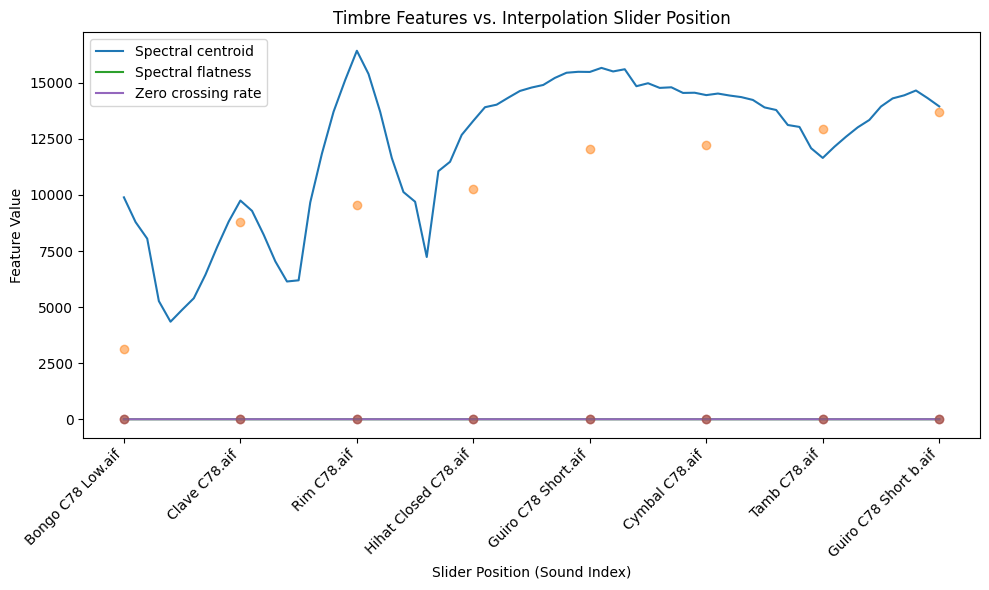

In [81]:
# Plot how each timbre feature changes as you move along the interpolation slider (resolution 0.1)

features = ['spectral_centroid', 'spectral_flatness', 'zero_crossing_rate']
slider_positions = np.arange(0, len(sorted_audio)-1 + 0.01, 0.1)

# For each slider position, interpolate in latent space, decode, and compute features
interp_feature_values = {feature: [] for feature in features}

resampled_encodings = resample_encodings(encodings, default_length)

def slider_to_audio(position:float, sorted_resampled_encodings:list):
    left_index = int(np.floor(position))
    right_index = min(left_index + 1, len(sorted_resampled_encodings) - 1)
    alpha = position - left_index
    interp_latent = interpolate_latents(sorted_resampled_encodings[left_index], sorted_resampled_encodings[right_index], alpha)
    recon_audio = model.decode(interp_latent)
    return recon_audio

for pos in slider_positions:
    recon_audio = slider_to_audio(pos, resampled_encodings)
    # Use sample rate from sorted_audio (all should be same)
    sr_interp = sorted_audio[int(np.floor(pos))]['sr']
    # Compute features on reconstructed audio
    centroid = li.feature.spectral_centroid(y=recon_audio, sr=sr_interp).mean()
    flatness = li.feature.spectral_flatness(y=recon_audio).mean()

    zero_cross = li.feature.zero_crossing_rate(y=recon_audio).mean()
    interp_feature_values['spectral_centroid'].append(centroid)
    interp_feature_values['spectral_flatness'].append(flatness)
    interp_feature_values['zero_crossing_rate'].append(zero_cross)

# Plot the computed features
plt.figure(figsize=(10, 6))
for feature in features:
    plt.plot(slider_positions, interp_feature_values[feature], label=feature.replace('_', ' ').capitalize())
    # Also plot original points for reference
    values = [audio[feature] for audio in sorted_audio]
    plt.plot(np.arange(len(values)), values, 'o', alpha=0.5)
    # print(np.array(interp_feature_values[feature]).shape, len(values))
    # print(interp_values.shape, len(values))

    # Compute and display correlation between each feature and slider position

    corr = np.corrcoef(slider_positions, interp_feature_values[feature])[0, 1]
    print(f"Correlation between '{feature.replace('_', ' ')}' and slider position: {corr:.3f}")
plt.xlabel('Slider Position (Sound Index)')
plt.ylabel('Feature Value')
plt.title('Timbre Features vs. Interpolation Slider Position')
plt.xticks(np.arange(len(sorted_audio)), [audio['filename'] for audio in sorted_audio], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [82]:
print('Use the sliders to interpolate between sounds and set encoding length.')
# print(f"Options: {[(selected_sounds[x], encodings[x][0].shape) for x in range(len(encodings))]}")
interact(interpolate_and_play, x=lerp_slider, length=length_slider, encodings=fixed(encodings), labels=fixed(selected_sounds))

Use the sliders to interpolate between sounds and set encoding length.


interactive(children=(FloatSlider(value=7.0, description='Interpolate', max=7.0, step=0.01), IntSlider(value=1…

<function __main__.interpolate_and_play(x, length, encodings, labels)>